# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

**ANSWER** 

The three outliers in the upper left corner have low first principal component (PC1) scores and high second principal component (PC2) scores. Since PC1 is mostly driven by series_3, this suggests those points have lower values of series_3. At the same time, their higher PC2 values mean series_1 and series_2 are relatively higher compared to series_3. It’s easier to say something about series_3 because it has the strongest influence on the first principal component. However, it’s much harder to distinguish between series_1 and series_2 because they are strongly related. This is because series_2 was created directly from series_1 with only a small amount of noise, so they move almost the same way and PCA treats them as one combined pattern. One advantage of this graph is that it reduces multiple variables into two dimensions and makes it easier to spot patterns and outliers. It also shows that most of the variation is coming from series_3. However, a disadvantage is that the principal components are harder to interpret and it becomes difficult to separate variables that are highly correlated like series_1 and series_2. Overall, the graph does show something interesting because it highlights how one variable (series_3) drives most of the variation, while the others behave very similarly.

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

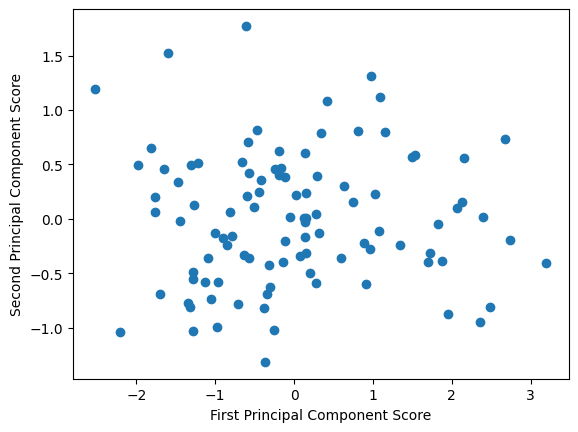

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [2]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download
path_marketing = kagglehub.dataset_download("imranalishahh/marketing-and-product-performance-dataset")
path_conversion = kagglehub.dataset_download("rabieelkharoua/predict-conversion-in-digital-marketing-dataset")
path_ads = kagglehub.dataset_download("nayakganesh007/google-ads-sales-dataset")

# Load
marketing = pd.read_csv(os.path.join(path_marketing, "marketing_and_product_performance.csv"))
conversion = pd.read_csv(os.path.join(path_conversion, "digital_marketing_campaign_dataset.csv"))
ads = pd.read_csv(os.path.join(path_ads, "GoogleAds_DataAnalytics_Sales_Uncleaned.csv"))

In [4]:
print("Marketing dataset shape:", marketing.shape)
print("Conversion dataset shape:", conversion.shape)
print("Ads dataset shape:", ads.shape)

print("\nConversion columns:")
print(conversion.columns)

Marketing dataset shape: (10000, 17)
Conversion dataset shape: (8000, 20)
Ads dataset shape: (2600, 13)

Conversion columns:
Index(['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel',
       'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate',
       'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares',
       'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints',
       'AdvertisingPlatform', 'AdvertisingTool', 'Conversion'],
      dtype='object')


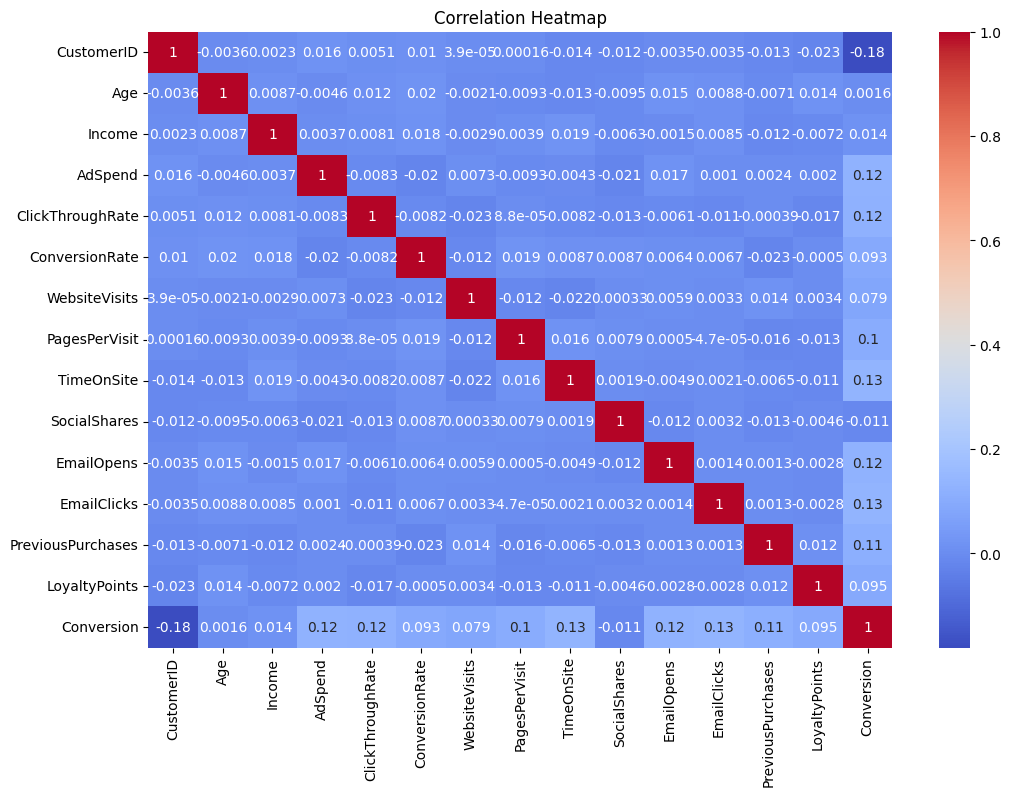

In [5]:
df = conversion

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**ANSWER**

The correlation heatmap shows that most variables have weak relationships with conversion outcomes. Advertising spend does not appear to have a strong correlation with conversion rate, which supports the earlier finding that spending alone does not drive performance. Engagement-related variables such as website visits, email clicks, and time on site show slightly stronger relationships with conversion, but these are still relatively low overall. This suggests that no single variable strongly predicts conversion outcomes. Instead, conversions are likely influenced by multiple factors working together. Overall, the heatmap reinforces the idea that marketing performance cannot be explained by one variable alone.

In [6]:
from sklearn.decomposition import PCA

# Only numeric columns
numeric_df = df.select_dtypes(include='number')

pca = PCA()
pca.fit(numeric_df)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[9.89190378e-01 5.64421674e-03 3.73449707e-03 1.42997263e-03
 5.84697379e-07 1.55507898e-07 1.43466457e-07 2.28300202e-08
 1.25070200e-08 5.84458717e-09 5.71476834e-09 4.75173460e-09
 6.56901876e-11 4.83594202e-12 2.07894051e-12]


**ANSWER**

The results of the Principal Component Analysis show that the first principal component explains approximately 98.9% of the total variance in the dataset. This indicates that most of the variability in the data can be captured using a single dimension. While this suggests that the dataset can be simplified, it also implies that many of the variables are related and move together in similar patterns. The remaining principal components contribute very little additional information. Because of this, using only the first principal component could represent the data reasonably well, but some detail may still be lost. Overall, the PCA results suggest that the data has a strong underlying structure, but multiple variables still contribute to understanding conversion outcomes.

**CONCLUSION**

Overall, the results from the multivariate analysis show that the data behaves somewhat as expected, but also highlights some important insights. The correlation heatmap showed that individual variables have weak relationships with conversion outcomes, while the PCA results showed that the data still follows a strong overall structure when considered together. This suggests that conversion outcomes are not driven by a single factor, but rather by multiple variables interacting at the same time. There were no extreme outliers, but some observations showed higher engagement levels than others, which may reflect differences in campaign performance. The dataset appears usable for further analysis, and PCA suggests that it may be possible to reduce the number of dimensions while still capturing most of the important information.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

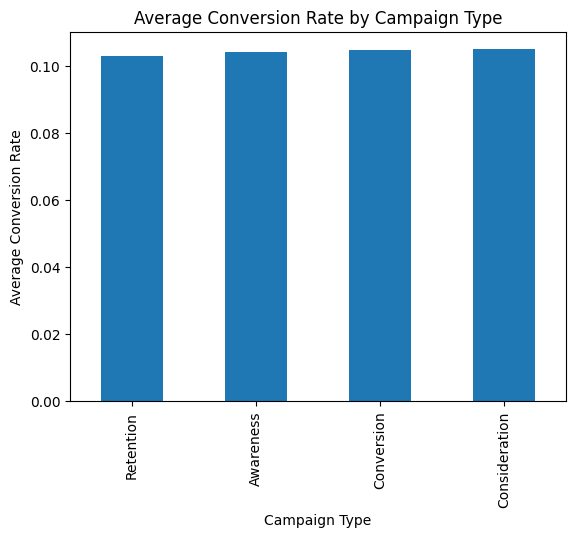

In [7]:
plt.figure()

# Group data
grouped = df.groupby('CampaignType')['ConversionRate'].mean().sort_values()

# Plot
grouped.plot(kind='bar')

# Title + labels
plt.title("Average Conversion Rate by Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("Average Conversion Rate")

plt.show()

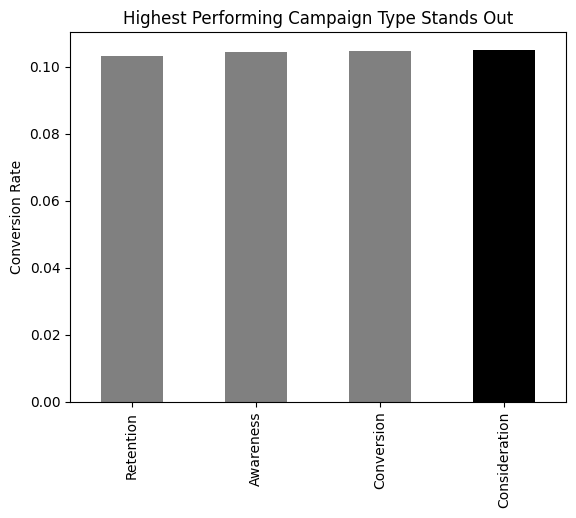

In [8]:
plt.figure()

grouped = df.groupby('CampaignType')['ConversionRate'].mean().sort_values()

colors = ['gray'] * len(grouped)
colors[-1] = 'black'  # highlight highest

grouped.plot(kind='bar', color=colors)

plt.title("Highest Performing Campaign Type Stands Out")
plt.xlabel("")
plt.ylabel("Conversion Rate")

plt.show()

**ANSWER**

This chart follows the Storytelling With Data approach by simplifying the visual and highlighting the most important category. Instead of treating all bars equally, the highest performing campaign type is emphasized using a darker color, which draws attention to the key insight. The rest of the bars are muted to reduce distraction and improve clarity. This makes it easier to quickly understand which campaign type performs best without overwhelming the viewer with unnecessary details.